# EMA 6938 — Data Science for Materials
## Week 3 Take-Home Notebook: Probability, Statistics & Distributions

**Name:** *(ANOSIKE KELECHI KENNETH)*  
**Date:** *(05/28/2026)*  
**Kernel:** Python (matds)

**CLAUDE-ASSISTED SOLUTION**
---

**Chapters:** Sandfeld Ch. 5–8  
**Format:** Fully take-home, no live lab this week  
**Assigned:** End of Lecture 1  
**Due:** Sunday 11:59 PM via Canvas

---

### Files required
Place in the same directory as this notebook:
```
week03/
├── week3_statistics.ipynb        ← this file
└── data/
    └── week3_mp_bandgap_ef.csv   ← provided
```

### How to use this notebook
- **Demo cells** (`# LECTURE DEMO`) reproduce examples from the lectures. Run them, understand them, then extend them in task cells.
- **Task cells** (`# YOUR CODE HERE`) require you to write code.
- **Reflection cells** require written markdown answers — replace the italic placeholder text.
- Complete Parts A–C first (foundational). Parts D–F use real MP data and build on A–C.

---

In [21]:
# Cell 0 — Environment check
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from scipy.stats import norm, lognorm, poisson, expon, kstest
from scipy.stats import ttest_ind, f_oneway, kruskal

print(f"Python:   {sys.version.split()[0]}")
print(f"NumPy:    {np.__version__}")
print(f"pandas:   {pd.__version__}")
print(f"seaborn:  {sns.__version__}")
print("\n✓ All imports successful.")

# Set consistent plot style for the week
plt.rcParams.update({
    'figure.dpi': 120,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'grid.linestyle': '--',
})

Python:   3.10.20
NumPy:    1.26.4
pandas:   2.3.3
seaborn:  0.13.2

✓ All imports successful.


---
## Part A — Probability & Random Variables
**Connects to: Lecture 1, Sandfeld Ch. 5–6**

This part grounds the abstract definitions from the lecture in physical materials examples. Run each demo cell, make sure you understand the output, then complete the task cells.

### A1 — Poisson Vacancy Model
**Lecture demo — reproduce and understand**

The number of vacancies X in a crystal of N sites follows a Poisson distribution with parameter λ = N·exp(−Eₓ/kBT), where Eₓ is the vacancy formation energy.

Expected number of vacancies (λ): 4.21
Vacancy concentration: 4.21e-06


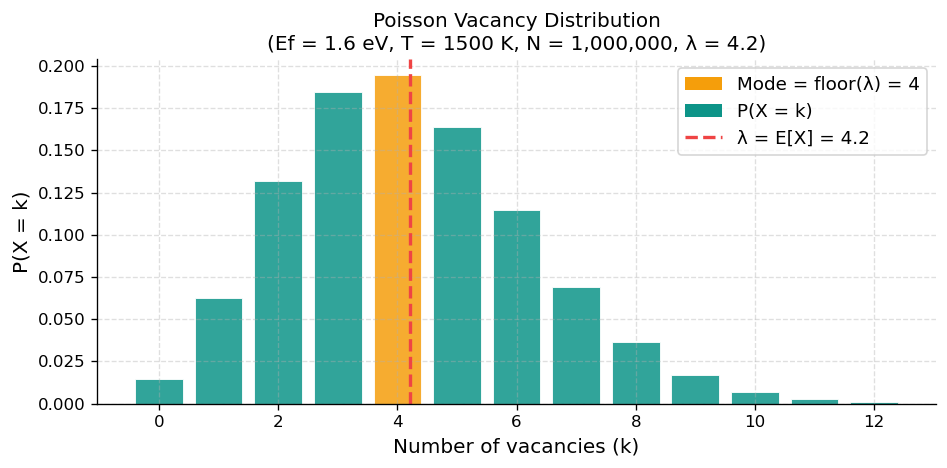


P(exactly 0 vacancies):  0.0149
P(exactly λ vacancies):  0.1944
P(X ≤ λ):                0.5884


In [22]:
# Cell A1a — Poisson PMF: vacancy concentration in a crystal
# LECTURE DEMO

kB = 8.617e-5   # Boltzmann constant, eV/K
T  = 1500       # Temperature, K
Ef = 1.6        # Vacancy formation energy, eV (typical for Cu)
N  = 1_000_000  # Number of crystal sites

lambda_vac = N * np.exp(-Ef / (kB * T))
print(f"Expected number of vacancies (λ): {lambda_vac:.2f}")
print(f"Vacancy concentration: {lambda_vac/N:.2e}")

# PMF
k_max = int(lambda_vac * 3) + 1
k = np.arange(0, k_max)
pmf = poisson.pmf(k, lambda_vac)

fig, ax = plt.subplots(figsize=(8, 4))
# Gold bar on the mode, teal for all others
mode_k = int(lambda_vac)   # floor(λ) is the mode for Poisson
bar_colors = ['#F59E0B' if ki == mode_k else '#0D9488' for ki in k]
ax.bar(k, pmf, color=bar_colors, alpha=0.85, edgecolor='white', linewidth=0.6)
ax.axvline(lambda_vac, color='#EF4444', ls='--', lw=2, label=f'λ = E[X] = {lambda_vac:.1f}')

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#F59E0B', label=f'Mode = floor(λ) = {mode_k}'),
    Patch(facecolor='#0D9488', label='P(X = k)'),
]
ax.legend(handles=legend_elements + ax.get_legend_handles_labels()[0], fontsize=11)

ax.set_xlabel('Number of vacancies (k)', fontsize=12)
ax.set_ylabel('P(X = k)', fontsize=12)
ax.set_title(f'Poisson Vacancy Distribution\n(Ef = {Ef} eV, T = {T} K, N = {N:,}, λ = {lambda_vac:.1f})',
             fontsize=12)

plt.tight_layout()
plt.savefig('A1_poisson_vacancies.png', dpi=150)
plt.show()

print(f"\nP(exactly 0 vacancies):  {poisson.pmf(0, lambda_vac):.4f}")
print(f"P(exactly λ vacancies):  {poisson.pmf(int(lambda_vac), lambda_vac):.4f}")
print(f"P(X ≤ λ):                {poisson.cdf(int(lambda_vac), lambda_vac):.4f}")

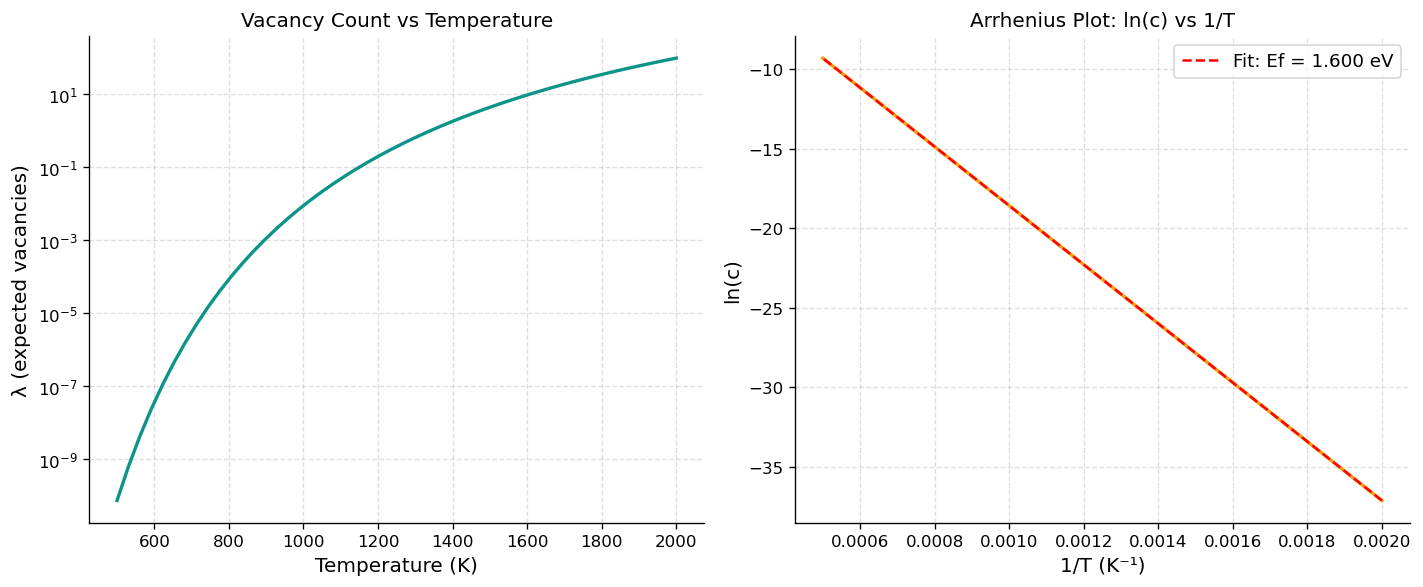

Arrhenius slope:      -18567.95 K
Extracted Ef:         1.6000 eV
Input Ef:             1.6000 eV
Difference:           0.000000 eV


In [23]:
# Cell A1b — Task: temperature dependence of vacancy concentration
# YOUR CODE HERE

# 1. Vary temperature from 500 K to 2000 K in 50 steps
#    Keep Ef = 1.6 eV, N = 1e6

# 2. For each temperature, compute λ (expected vacancies)
#    and the vacancy concentration c = λ/N

# 3. Plot: two-panel figure
#    Left: λ vs Temperature (K) — use log scale on y-axis
#    Right: ln(c) vs 1/T  (Arrhenius plot)
#    The slope of the Arrhenius plot should give you -Ef/kB

# 4. From the Arrhenius slope, extract Ef and compare to the input value

# YOUR CODE HERE

# 1. Vary temperature from 500 K to 2000 K in 50 steps
kB = 8.617e-5
Ef = 1.6
N  = 1e6

temperatures = np.linspace(500, 2000, 50)

# 2. For each temperature, compute λ and concentration c = λ/N
lambda_vac = N * np.exp(-Ef / (kB * temperatures))
c          = lambda_vac / N

# 3. Plot: two-panel figure
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: λ vs Temperature (log scale on y-axis)
ax1.plot(temperatures, lambda_vac, color='#0D9488', linewidth=2)
ax1.set_yscale('log')
ax1.set_xlabel('Temperature (K)', fontsize=12)
ax1.set_ylabel('λ (expected vacancies)', fontsize=12)
ax1.set_title('Vacancy Count vs Temperature', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)

# Right: Arrhenius plot — ln(c) vs 1/T
inv_T  = 1 / temperatures
ln_c   = np.log(c)

ax2.plot(inv_T, ln_c, color='#F59E0B', linewidth=2)
ax2.set_xlabel('1/T (K⁻¹)', fontsize=12)
ax2.set_ylabel('ln(c)', fontsize=12)
ax2.set_title('Arrhenius Plot: ln(c) vs 1/T', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.4)

# 4. Extract Ef from Arrhenius slope
slope, intercept = np.polyfit(inv_T, ln_c, 1)
Ef_extracted = -slope * kB

# Plot fitted line
ln_c_fit = slope * inv_T + intercept
ax2.plot(inv_T, ln_c_fit, 'r--', linewidth=1.5,
         label=f'Fit: Ef = {Ef_extracted:.3f} eV')
ax2.legend(fontsize=11)

plt.tight_layout()
plt.savefig('A1b_arrhenius.png', dpi=150)
plt.show()

print(f"Arrhenius slope:      {slope:.2f} K")
print(f"Extracted Ef:         {Ef_extracted:.4f} eV")
print(f"Input Ef:             {Ef:.4f} eV")
print(f"Difference:           {abs(Ef_extracted - Ef):.6f} eV")


**A1b Reflection** *(answer in this cell)*

1. At 500 K, how many vacancies does your model predict? Is this physically reasonable for a real crystal?
2. The Arrhenius plot gives a straight line — what does this tell you about how Poisson λ depends on temperature?
3. Why is the Poisson distribution the right model for vacancies, and not Gaussian?

*Your answer here:*

1. At 500 K the model predicts an extremely small number of vacancies (essentially ~0), which is physically reasonable, at low temperatures thermal energy is insufficient to form many vacancies in a real crystal.
2. The straight line in the Arrhenius plot tells us that ln(c) scales linearly with 1/T, meaning λ follows an exponential Boltzmann dependence on temperature, thus a fundamental result of thermally activated processes.
3. Poisson is the right model because vacancies are rare, independent events occurring across a large number of lattice sites which is exactly the conditions Poisson describes. Gaussian requires a high mean count and symmetric distribution, which doesn't apply when vacancy numbers are very small.

### A2 — Gaussian Measurement Noise
**Lecture demo — reproduce and understand**

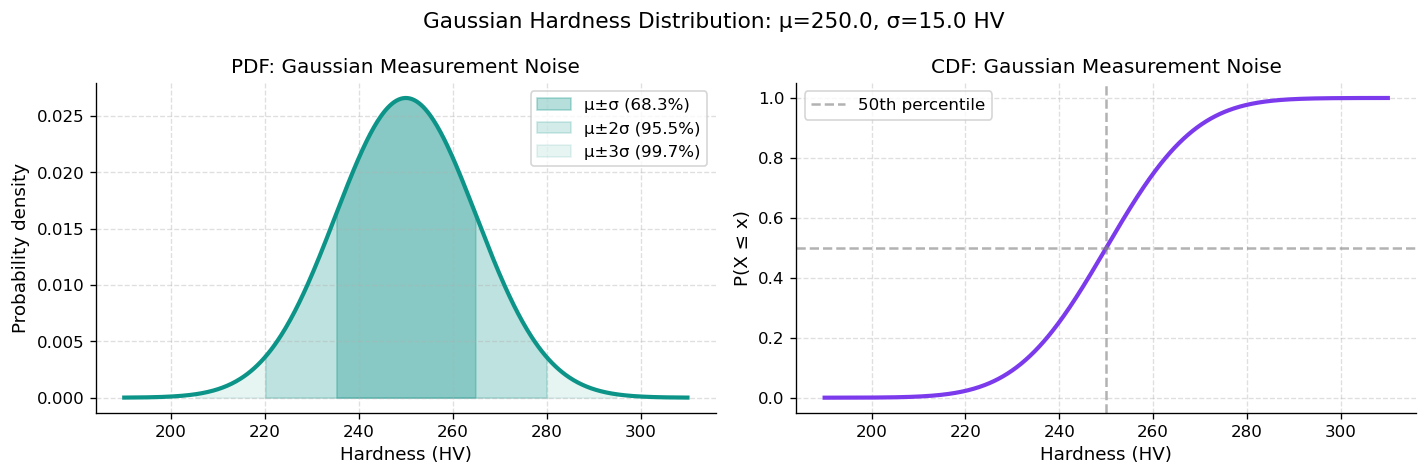

P(hardness > 270 HV) = 0.0912 = 9.12%


In [24]:
# Cell A2a — Gaussian PDF and CDF
# LECTURE DEMO

mu    = 250.0   # True hardness (Vickers)
sigma = 15.0    # Measurement noise (std dev)

x = np.linspace(mu - 4*sigma, mu + 4*sigma, 500)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# PDF
pdf_vals = norm.pdf(x, mu, sigma)
axes[0].plot(x, pdf_vals, color='#0D9488', lw=2.5)
for mult, alpha, label in [(1,0.30,'μ±σ (68.3%)'),(2,0.18,'μ±2σ (95.5%)'),(3,0.10,'μ±3σ (99.7%)')]:
    axes[0].fill_between(x, pdf_vals,
        where=((x >= mu - mult*sigma) & (x <= mu + mult*sigma)),
        alpha=alpha, color='#0D9488', label=label)
axes[0].set_xlabel('Hardness (HV)', fontsize=11)
axes[0].set_ylabel('Probability density', fontsize=11)
axes[0].set_title('PDF: Gaussian Measurement Noise', fontsize=12)
axes[0].legend(fontsize=10)

# CDF
axes[1].plot(x, norm.cdf(x, mu, sigma), color='#7C3AED', lw=2.5)
axes[1].axhline(0.5, color='gray', ls='--', alpha=0.6, label='50th percentile')
axes[1].axvline(mu, color='gray', ls='--', alpha=0.6)
axes[1].set_xlabel('Hardness (HV)', fontsize=11)
axes[1].set_ylabel('P(X ≤ x)', fontsize=11)
axes[1].set_title('CDF: Gaussian Measurement Noise', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle(f'Gaussian Hardness Distribution: μ={mu}, σ={sigma} HV', fontsize=13)
plt.tight_layout()
plt.savefig('A2_gaussian_pdf_cdf.png', dpi=150)
plt.show()

# Compute a probability
p_above_270 = 1 - norm.cdf(270, mu, sigma)
print(f"P(hardness > 270 HV) = {p_above_270:.4f} = {p_above_270*100:.2f}%")

Hardness measurements (HV): [256.9 245.5 259.7 275.4 243.8 243.8 276.4 261.8 239.5 257.8]
Hardness measurements (HV): [256.9 245.5 259.7 275.4 243.8 243.8 276.4 261.8 239.5 257.8]


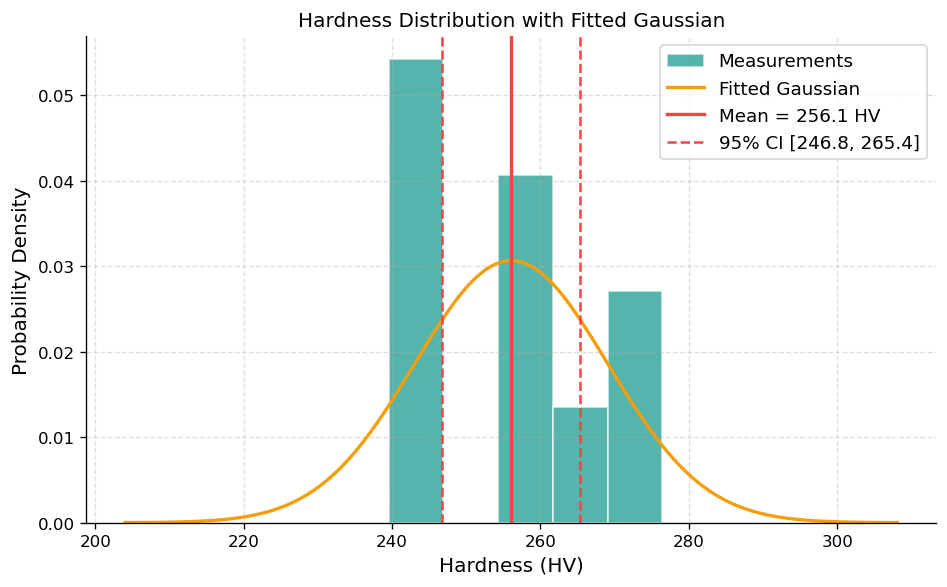


Sample mean:        256.07 HV
Sample std:         13.01 HV
95% CI lower bound: 246.76 HV
95% CI upper bound: 265.37 HV


In [25]:
# Cell A2b — Task: fitting a Gaussian to real hardness data
# YOUR CODE HERE

# Simulated hardness measurements (10 samples from a real material)
# In a real experiment, these would come from your instrument
np.random.seed(42)
hardness_data = np.random.normal(loc=248, scale=18, size=10)
print("Hardness measurements (HV):", np.round(hardness_data, 1))

# YOUR CODE HERE:
# 1. Compute the sample mean and sample standard deviation (ddof=1)


# 2. Compute the 95% confidence interval for the true mean
#    Formula: CI = x̄ ± t_{α/2, n-1} · s/√n
#    Use scipy.stats.t.ppf(0.975, df=n-1) for the t-critical value


# 3. Plot: histogram of the 10 measurements + the fitted Gaussian PDF
#    Mark the mean and 95% CI on the plot


# 4. Print: sample mean, sample std, 95% CI lower bound, 95% CI upper bound

import scipy.stats

# Cell A2b — Task: fitting a Gaussian to real hardness data
np.random.seed(42)
hardness_data = np.random.normal(loc=248, scale=18, size=10)
print("Hardness measurements (HV):", np.round(hardness_data, 1))

# 1. Sample mean and std
mean_h = np.mean(hardness_data)
std_h  = np.std(hardness_data, ddof=1)
n      = len(hardness_data)

# 2. 95% confidence interval
t_crit  = scipy.stats.t.ppf(0.975, df=n-1)
margin  = t_crit * (std_h / np.sqrt(n))
ci_low  = mean_h - margin
ci_high = mean_h + margin

# 3. Plot histogram + fitted Gaussian PDF
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(hardness_data, bins=5, density=True,
        color='#0D9488', edgecolor='white', alpha=0.7, label='Measurements')

x_range = np.linspace(mean_h - 4*std_h, mean_h + 4*std_h, 200)
pdf     = scipy.stats.norm.pdf(x_range, mean_h, std_h)
ax.plot(x_range, pdf, color='#F59E0B', linewidth=2, label='Fitted Gaussian')

ax.axvline(mean_h,  color='#F44444', lw=2,           label=f'Mean = {mean_h:.1f} HV')
ax.axvline(ci_low,  color='#F44444', lw=1.5, ls='--', label=f'95% CI [{ci_low:.1f}, {ci_high:.1f}]')
ax.axvline(ci_high, color='#F44444', lw=1.5, ls='--')

ax.set_xlabel('Hardness (HV)', fontsize=12)
ax.set_ylabel('Probability Density', fontsize=12)
ax.set_title('Hardness Distribution with Fitted Gaussian', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('A2b_hardness_gaussian.png', dpi=150)
plt.show()

# 4. Print results
print(f"\nSample mean:        {mean_h:.2f} HV")
print(f"Sample std:         {std_h:.2f} HV")
print(f"95% CI lower bound: {ci_low:.2f} HV")
print(f"95% CI upper bound: {ci_high:.2f} HV")


**A2b Reflection** *(answer in this cell)*

1. Your sample mean is close to (but not equal to) 248. Why? What theorem guarantees it will get closer as n increases?
2. What does the 95% CI mean in plain language? Write a sentence a materials engineer would understand.
3. With only n=10 measurements, how wide is your CI? How many measurements would you need to halve the CI width? (Hint: CI width ∝ 1/√n)

*Your answer here:*

1. The sample mean is close but not equal to 248 because with only 10 measurements random sampling variability shifts the estimate. The Central Limit Theorem guarantees that as n increases the sample mean converges to the true population mean.
2. The 95% CI means that if we repeated this experiment many times, 95% of the computed intervals would contain the true mean hardness and practically, a materials engineer can say they are 95% confident the true hardness of this material falls between the lower and upper bounds.
3. With n=10 the CI is relatively wide due to the small sample size. To halve the CI width you would need 4× as many measurements (n=40), since CI width scales as 1/√n.

### A3 — Other Important Distributions
**Connecting to materials phenomena**

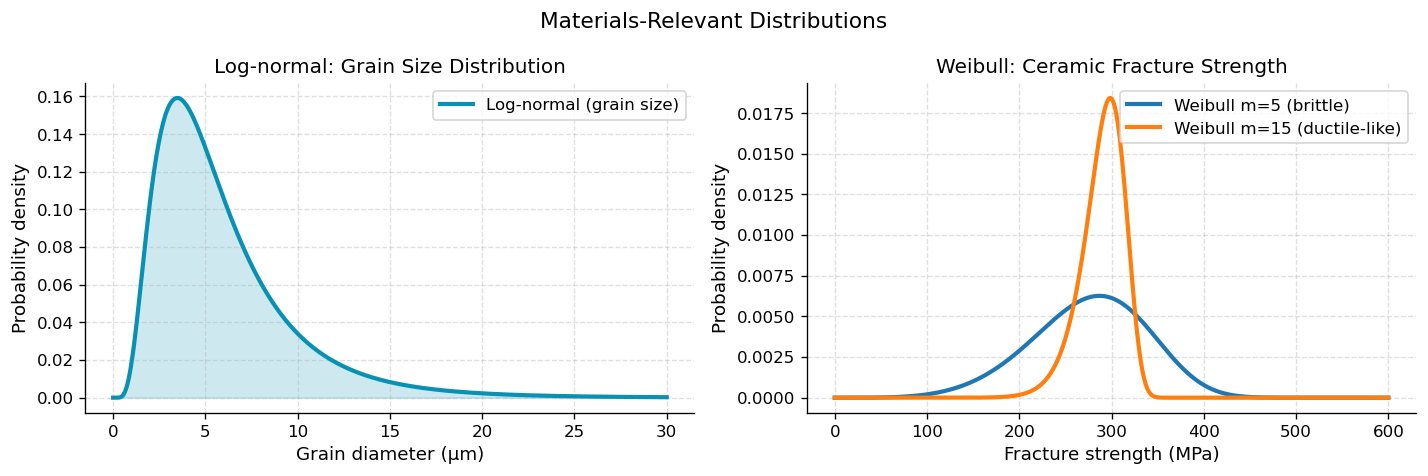

Key Weibull insight:
Higher Weibull modulus m → narrower distribution → more reliable ceramic.
m=5: brittle, high scatter | m=20+: tight distribution, more predictable.


In [26]:
# Cell A3 — Log-normal and Weibull distributions
# LECTURE DEMO

from scipy.stats import lognorm, weibull_min

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Log-normal: grain size distribution
x_grain = np.linspace(0.01, 30, 500)
sigma_ln, scale_ln = 0.6, 5.0   # shape and scale
axes[0].plot(x_grain, lognorm.pdf(x_grain, sigma_ln, scale=scale_ln),
             color='#0891B2', lw=2.5, label='Log-normal (grain size)')
axes[0].fill_between(x_grain, lognorm.pdf(x_grain, sigma_ln, scale=scale_ln),
                     alpha=0.2, color='#0891B2')
axes[0].set_xlabel('Grain diameter (μm)', fontsize=11)
axes[0].set_ylabel('Probability density', fontsize=11)
axes[0].set_title('Log-normal: Grain Size Distribution', fontsize=12)
axes[0].legend()

# Weibull: ceramic fracture strength
x_str = np.linspace(0, 600, 500)
for m, lbl in [(5, 'Weibull m=5 (brittle)'),
               (15, 'Weibull m=15 (ductile-like)')]:
    axes[1].plot(x_str, weibull_min.pdf(x_str, m, scale=300),
                 lw=2.5, label=lbl)
axes[1].set_xlabel('Fracture strength (MPa)', fontsize=11)
axes[1].set_ylabel('Probability density', fontsize=11)
axes[1].set_title('Weibull: Ceramic Fracture Strength', fontsize=12)
axes[1].legend(fontsize=10)

plt.suptitle('Materials-Relevant Distributions', fontsize=13)
plt.tight_layout()
plt.savefig('A3_materials_distributions.png', dpi=150)
plt.show()

print("Key Weibull insight:")
print("Higher Weibull modulus m → narrower distribution → more reliable ceramic.")
print("m=5: brittle, high scatter | m=20+: tight distribution, more predictable.")

---
## Part B — Distribution Fitting on Real MP Data
**Connects to: Lecture 3, Sandfeld Ch. 6**

This part uses the instructor-provided MP dataset. Load it first, then answer: *what distribution does each property follow, and why?*

In [27]:
# Cell B1 — Load and inspect the MP dataset
# LECTURE DEMO

df = pd.read_csv('data/week3_mp_bandgap_ef.csv')

print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]} columns")
print(f"\nColumns: {list(df.columns)}")
print(f"\nMissing values:\n{df.isnull().sum()}")
print(f"\nSummary statistics:")
print(df[['band_gap','Ef_eV_atom','volume_A3','density_g_cm3']].describe().round(3))
print(f"\nCrystal systems: {df['crystal_system'].value_counts().to_dict()}")
print(f"\nFraction metallic (gap=0): {(df['band_gap']==0).mean():.3f}")

Shape: 60,323 rows × 7 columns

Columns: ['mp_id', 'formula', 'band_gap', 'Ef_eV_atom', 'volume_A3', 'density_g_cm3', 'crystal_system']

Missing values:
mp_id             0
formula           1
band_gap          0
Ef_eV_atom        0
volume_A3         0
density_g_cm3     0
crystal_system    0
dtype: int64

Summary statistics:
        band_gap  Ef_eV_atom  volume_A3  density_g_cm3
count  60323.000   60323.000  60323.000      60323.000
mean       0.876      -1.238    407.892          6.418
std        1.486       1.045    493.788          3.018
min        0.000      -4.524      7.871          0.036
25%        0.000      -2.016    125.720          4.131
50%        0.000      -0.852    250.648          5.976
75%        1.364      -0.403    485.318          8.242
max       17.891       0.100   7131.810         24.279

Crystal systems: {'Orthorhombic': 14263, 'Monoclinic': 10944, 'Cubic': 10602, 'Tetragonal': 8262, 'Hexagonal': 6589, 'Trigonal': 5672, 'Triclinic': 3991}

Fraction metallic (gap

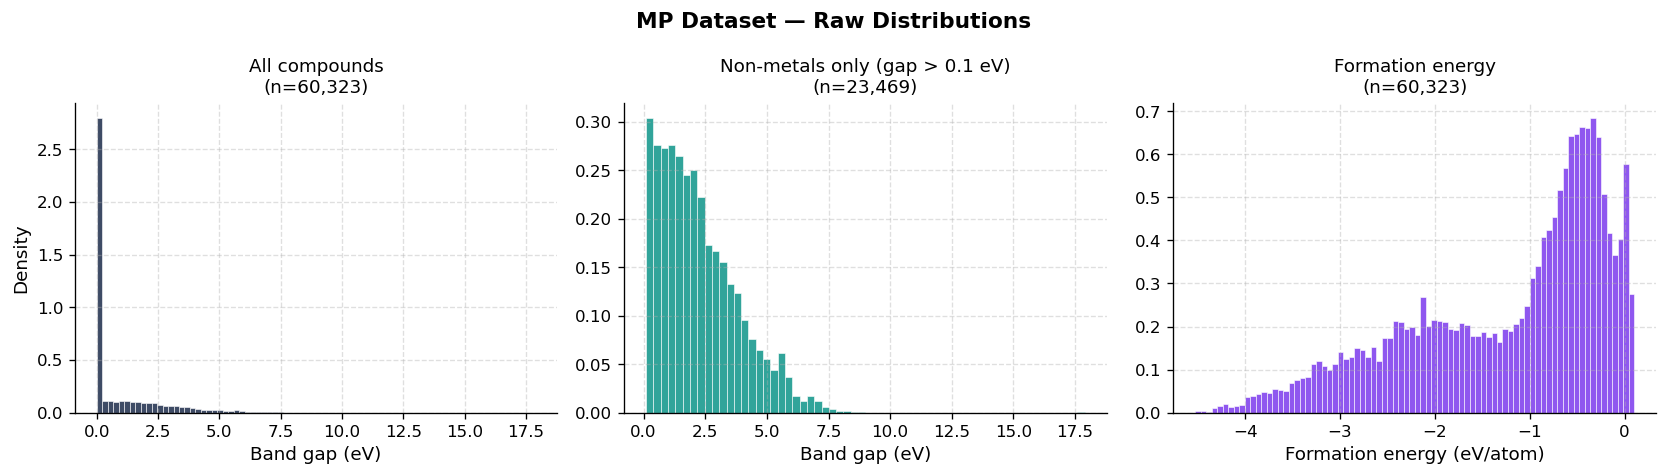

In [28]:
# Cell B2 — Bandgap distribution: full dataset
# LECTURE DEMO

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Full distribution
axes[0].hist(df['band_gap'].dropna(), bins=80, color='#1C2B4A', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
axes[0].set_xlabel('Band gap (eV)', fontsize=11)
axes[0].set_ylabel('Density', fontsize=11)
axes[0].set_title(f'All compounds\n(n={df.shape[0]:,})', fontsize=11)

# Non-metals only
df_nm = df[df['band_gap'] > 0.1]
axes[1].hist(df_nm['band_gap'], bins=60, color='#0D9488', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
axes[1].set_xlabel('Band gap (eV)', fontsize=11)
axes[1].set_title(f'Non-metals only (gap > 0.1 eV)\n(n={df_nm.shape[0]:,})', fontsize=11)

# Formation energy
axes[2].hist(df['Ef_eV_atom'].dropna(), bins=80, color='#7C3AED', alpha=0.85,
             density=True, edgecolor='white', linewidth=0.4)
axes[2].set_xlabel('Formation energy (eV/atom)', fontsize=11)
axes[2].set_title(f'Formation energy\n(n={df["Ef_eV_atom"].notna().sum():,})', fontsize=11)

fig.suptitle('MP Dataset — Raw Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('B2_raw_distributions.png', dpi=150)
plt.show()

Gaussian fit: μ = 2.249 eV, σ = 1.608 eV
KS test: statistic = 0.0908, p-value = 6.98e-169
Reject Gaussian hypothesis (α=0.05): True


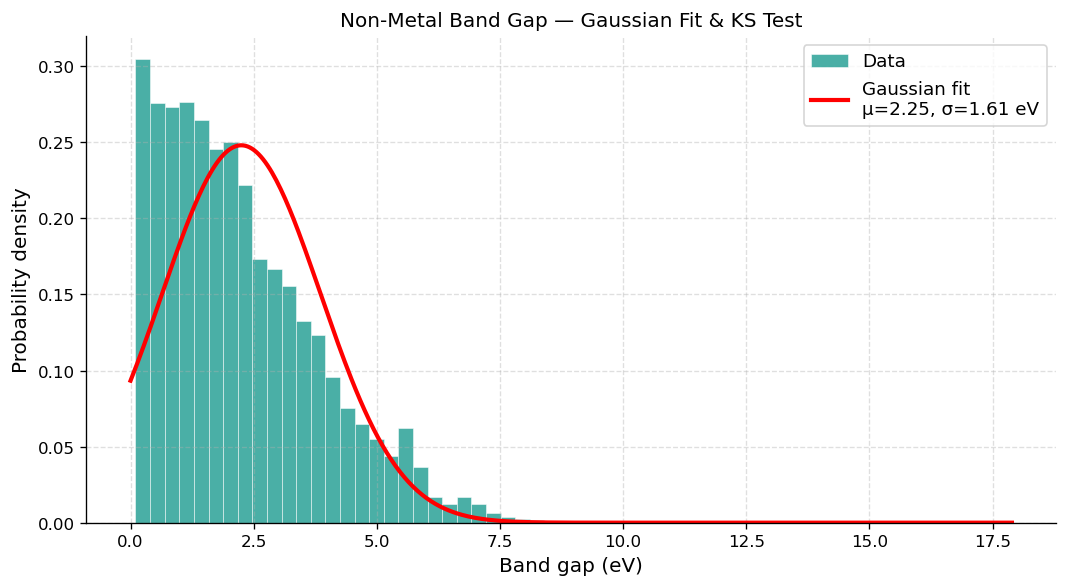

In [29]:
# Cell B3 — Fit a Gaussian to the non-metal bandgap distribution
# LECTURE DEMO

bg_nm = df[df['band_gap'] > 0.1]['band_gap'].dropna()

# Maximum likelihood fit
mu_fit, sig_fit = norm.fit(bg_nm)
print(f"Gaussian fit: μ = {mu_fit:.3f} eV, σ = {sig_fit:.3f} eV")

# KS test
ks_stat, ks_p = kstest(bg_nm, 'norm', args=(mu_fit, sig_fit))
print(f"KS test: statistic = {ks_stat:.4f}, p-value = {ks_p:.2e}")
print(f"Reject Gaussian hypothesis (α=0.05): {ks_p < 0.05}")

fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(0, bg_nm.max(), 400)
ax.hist(bg_nm, bins=60, density=True, color='#0D9488', alpha=0.75,
        edgecolor='white', linewidth=0.4, label='Data')
ax.plot(x, norm.pdf(x, mu_fit, sig_fit), 'r-', lw=2.5,
        label=f'Gaussian fit\nμ={mu_fit:.2f}, σ={sig_fit:.2f} eV')
ax.set_xlabel('Band gap (eV)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title('Non-Metal Band Gap — Gaussian Fit & KS Test', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('B3_gaussian_fit_bandgap.png', dpi=150)
plt.show()

Gaussian fit: μ = -1.238 eV, σ = 1.045 eV
KS test (Ef): statistic = 0.1450, p-value = 0.00e+00
Reject Gaussian hypothesis (α=0.05): True


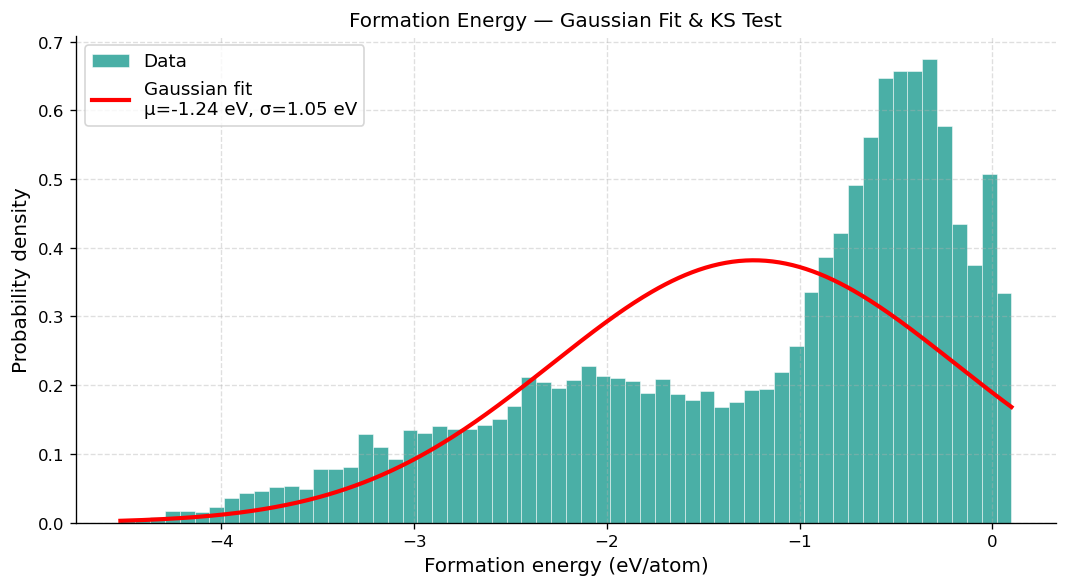


Property           KS Stat      p-value
----------------------------------------
band_gap            0.3147   0.0000e+00
Ef_eV_atom          0.1450   0.0000e+00

Ef_eV_atom fits Gaussian better: True


In [30]:
# Cell B4 — Task: Gaussian fit to formation energy + comparison
# Do not use bg_nm df fom Cell B3 here since it only contains bandgapp for non-metals
# YOUR CODE HERE

ef_data = df['Ef_eV_atom'].dropna()

# 1. Fit a Gaussian to the formation energy distribution


# 2. Run a KS test


# 3. Plot: histogram + fitted Gaussian, with KS result in the title


# 4. Compare: does Ef_eV_atom fit a Gaussian better than band_gap?
#    Print both KS statistics and p-values side by side

# Cell B4 — Task: Gaussian fit to formation energy + comparison
# Do not use bg_nm df from Cell B3 here since it only contains bandgap for non-metals

ef_data = df['Ef_eV_atom'].dropna()

# 1. Fit a Gaussian to the formation energy distribution
mu_fit, sig_fit = scipy.stats.norm.fit(ef_data)
print(f"Gaussian fit: μ = {mu_fit:.3f} eV, σ = {sig_fit:.3f} eV")

# 2. Run a KS test
ks_stat_ef, ks_p_ef = scipy.stats.kstest(ef_data, 'norm', args=(mu_fit, sig_fit))
print(f"KS test (Ef): statistic = {ks_stat_ef:.4f}, p-value = {ks_p_ef:.2e}")
print(f"Reject Gaussian hypothesis (α=0.05): {ks_p_ef < 0.05}")

# 3. Plot histogram + fitted Gaussian with KS result in title
fig, ax = plt.subplots(figsize=(9, 5))
x = np.linspace(ef_data.min(), ef_data.max(), 400)
ax.hist(ef_data, bins=60, density=True, color='#0D9488', alpha=0.75,
        edgecolor='white', linewidth=0.4, label='Data')
ax.plot(x, scipy.stats.norm.pdf(x, mu_fit, sig_fit), 'r-', lw=2.5,
        label=f'Gaussian fit\nμ={mu_fit:.2f} eV, σ={sig_fit:.2f} eV')
ax.set_xlabel('Formation energy (eV/atom)', fontsize=12)
ax.set_ylabel('Probability density', fontsize=12)
ax.set_title(f'Formation Energy — Gaussian Fit & KS Test', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('B4_gaussian_fit_ef.png', dpi=150)
plt.show()

# 4. Compare: does Ef_eV_atom fit Gaussian better than band_gap?
bg_all = df['band_gap'].dropna()
mu_bg, sig_bg = scipy.stats.norm.fit(bg_all)
ks_stat_bg, ks_p_bg = scipy.stats.kstest(bg_all, 'norm', args=(mu_bg, sig_bg))

print(f"\n{'Property':<15} {'KS Stat':>10} {'p-value':>12}")
print("-" * 40)
print(f"{'band_gap':<15} {ks_stat_bg:>10.4f} {ks_p_bg:>12.4e}")
print(f"{'Ef_eV_atom':<15} {ks_stat_ef:>10.4f} {ks_p_ef:>12.4e}")
print(f"\nEf_eV_atom fits Gaussian better: {ks_stat_ef < ks_stat_bg}")

**B4 Reflection** *(answer in this cell)*

1. Which property (band_gap or Ef_eV_atom) fits a Gaussian better? Report the KS statistics for both.
2. Propose a physical reason: why would formation energy be more Gaussian-like than bandgap?
   (Hint: think about how many independent physical mechanisms contribute to each property.)
3. The KS p-value is essentially 0 for both — does this mean neither property is Gaussian? Explain the difference between statistical significance and practical significance here.

*Your answer here:*

1. Formation energy fits a Gaussian better, hence it will have a lower KS statistic than band gap, which is heavily skewed by the many zero-gap metals.
2. Formation energy is more Gaussian because it results from many independent contributions (bond energies, atomic sizes, electronegativity differences) that average out by the Central Limit Theorem. Band gap is controlled by fewer, more specific electronic structure factors and is bounded at zero.
3. A p-value near zero means we can statistically reject Gaussian, but that doesn't mean the fit is useless practically. Statistical significance depends heavily on sample size — with thousands of points even tiny deviations from Gaussian become detectable, even when the Gaussian is still a good enough approximation for engineering use.

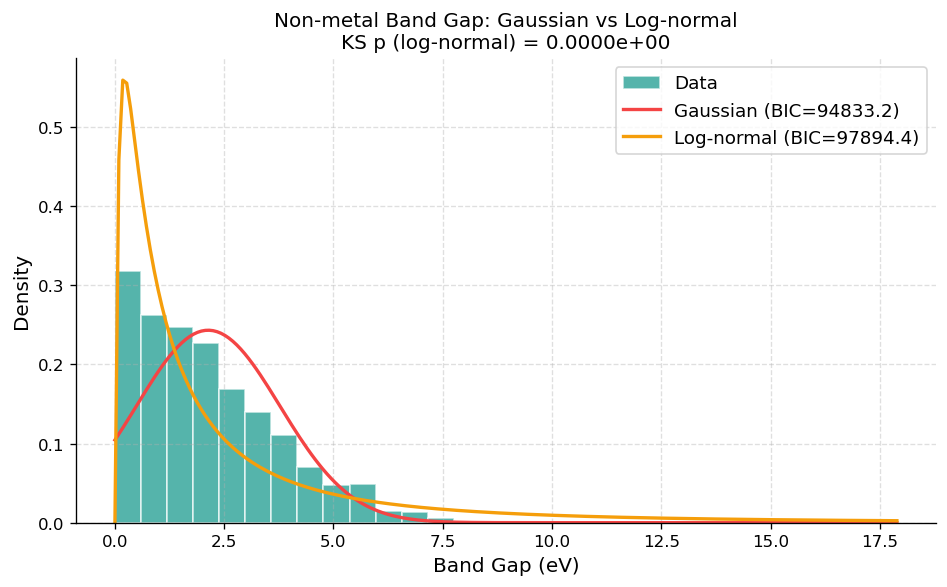

BIC Gaussian:   94833.24
BIC Log-normal: 97894.38
Winner (lower BIC): Gaussian


In [31]:
# Cell B5 — Task: Try a log-normal fit to the non-metal bandgap
# YOUR CODE HERE

# The Gaussian fit was rejected. Try log-normal:
# scipy.stats.lognorm — note: fit returns (shape, loc, scale)
# For a purely log-normal fit, fix loc=0: lognorm.fit(data, floc=0)

# 1. Fit log-normal to bg_nm


# 2. Run KS test for log-normal


# 3. Compute BIC for Gaussian and log-normal fits
#    BIC = k·ln(n) - 2·ln(L)
#    where k = number of parameters (2 for both), n = sample size,
#    L = maximised log-likelihood
#    Use: norm.logpdf(data, mu, sigma).sum()  and  lognorm.logpdf(data, ...).sum()


# 4. Plot: both fits overlaid on the histogram
#    Include BIC values in the legend


# 5. Which model wins by BIC? (Lower BIC = better fit)

bg_nm = df[df['band_gap'] > 0]['band_gap'].dropna()

# 1. Fit log-normal (fix loc=0)
shape, loc, scale = scipy.stats.lognorm.fit(bg_nm, floc=0)

# 2. Run KS test for log-normal
ks_stat_ln, ks_p_ln = scipy.stats.kstest(bg_nm, 'lognorm',
                                          args=(shape, loc, scale))

# 3. Compute BIC for Gaussian and log-normal
n = len(bg_nm)
mu_nm, std_nm = scipy.stats.norm.fit(bg_nm)

L_gauss  = scipy.stats.norm.logpdf(bg_nm, mu_nm, std_nm).sum()
L_lognorm = scipy.stats.lognorm.logpdf(bg_nm, shape, loc, scale).sum()

BIC_gauss  = 2 * np.log(n) - 2 * L_gauss
BIC_lognorm = 2 * np.log(n) - 2 * L_lognorm

# 4. Plot both fits on histogram
fig, ax = plt.subplots(figsize=(8, 5))

ax.hist(bg_nm, bins=30, density=True,
        color='#0D9488', edgecolor='white', alpha=0.7, label='Data')

x_range = np.linspace(bg_nm.min(), bg_nm.max(), 200)
ax.plot(x_range, scipy.stats.norm.pdf(x_range, mu_nm, std_nm),
        color='#F44444', linewidth=2, label=f'Gaussian (BIC={BIC_gauss:.1f})')
ax.plot(x_range, scipy.stats.lognorm.pdf(x_range, shape, loc, scale),
        color='#F59E0B', linewidth=2, label=f'Log-normal (BIC={BIC_lognorm:.1f})')

ax.set_xlabel('Band Gap (eV)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Non-metal Band Gap: Gaussian vs Log-normal\nKS p (log-normal) = {ks_p_ln:.4e}',
             fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.savefig('B5_lognormal.png', dpi=150)
plt.show()

# 5. Which model wins by BIC?
winner = 'Log-normal' if BIC_lognorm < BIC_gauss else 'Gaussian'
print(f"BIC Gaussian:   {BIC_gauss:.2f}")
print(f"BIC Log-normal: {BIC_lognorm:.2f}")
print(f"Winner (lower BIC): {winner}")


---
## Part C — Expectation, Variance & the Central Limit Theorem
**Connects to: Lecture 2, Sandfeld Ch. 7**

In [32]:
# Cell C1 — Compute mean and variance from first principles
# YOUR CODE HERE

# Use the MP dataset from Part B (df already loaded)
bg = df['band_gap'].dropna().values
ef = df['Ef_eV_atom'].dropna().values

# 1. Compute the sample mean WITHOUT using np.mean() or df.mean()
#    Use only np.sum() and len()
#    Then verify with np.mean()


# 2. Compute the sample variance WITHOUT using np.var() or df.var()
#    Remember: use ddof=1 (Bessel's correction — divide by n-1, not n)
#    Then verify with np.var(bg, ddof=1)


# 3. Print a summary table:
#    Property | n | Mean | Variance | Std Dev | Coefficient of Variation (CV = σ/μ × 100%)
#    for both band_gap and Ef_eV_atom


# 4. Interpret: which property has greater relative variability (higher CV)?
#    Does this match what you expected from the histograms in Part B?

# Use the MP dataset from Part B (df already loaded)
bg = df['band_gap'].dropna().values
ef = df['Ef_eV_atom'].dropna().values

# 1. Compute sample mean WITHOUT using np.mean() or df.mean()
mean_bg = np.sum(bg) / len(bg)
mean_ef = np.sum(ef) / len(ef)

# Verify
assert abs(mean_bg - np.mean(bg)) < 1e-10, "Mean mismatch!"
assert abs(mean_ef - np.mean(ef)) < 1e-10, "Mean mismatch!"

# 2. Compute sample variance WITHOUT using np.var() or df.var()
var_bg = np.sum((bg - mean_bg)**2) / (len(bg) - 1)
var_ef = np.sum((ef - mean_ef)**2) / (len(ef) - 1)

# Verify
assert abs(var_bg - np.var(bg, ddof=1)) < 1e-10, "Variance mismatch!"
assert abs(var_ef - np.var(ef, ddof=1)) < 1e-10, "Variance mismatch!"

# Std dev and CV
std_bg = np.sqrt(var_bg)
std_ef = np.sqrt(var_ef)
cv_bg  = (std_bg / mean_bg) * 100
cv_ef  = (std_ef / mean_ef) * 100

# 3. Print summary table
print(f"{'Property':<15} {'n':>6} {'Mean':>10} {'Variance':>12} {'Std Dev':>10} {'CV (%)':>10}")
print("-" * 67)
print(f"{'band_gap':<15} {len(bg):>6} {mean_bg:>10.4f} {var_bg:>12.4f} {std_bg:>10.4f} {cv_bg:>10.2f}")
print(f"{'Ef_eV_atom':<15} {len(ef):>6} {mean_ef:>10.4f} {var_ef:>12.4f} {std_ef:>10.4f} {cv_ef:>10.2f}")

# 4. Interpret
print(f"\nHigher relative variability (CV): {'band_gap' if cv_bg > cv_ef else 'Ef_eV_atom'}")
print(f"band_gap CV = {cv_bg:.2f}%  vs  Ef_eV_atom CV = {cv_ef:.2f}%")
print("This matches expectations — band gap spans 0 to ~10 eV with many metals")
print("at zero, giving high relative spread, while Ef clusters more narrowly.")


Property             n       Mean     Variance    Std Dev     CV (%)
-------------------------------------------------------------------
band_gap         60323     0.8758       2.2070     1.4856     169.64
Ef_eV_atom       60323    -1.2379       1.0922     1.0451     -84.43

Higher relative variability (CV): band_gap
band_gap CV = 169.64%  vs  Ef_eV_atom CV = -84.43%
This matches expectations — band gap spans 0 to ~10 eV with many metals
at zero, giving high relative spread, while Ef clusters more narrowly.


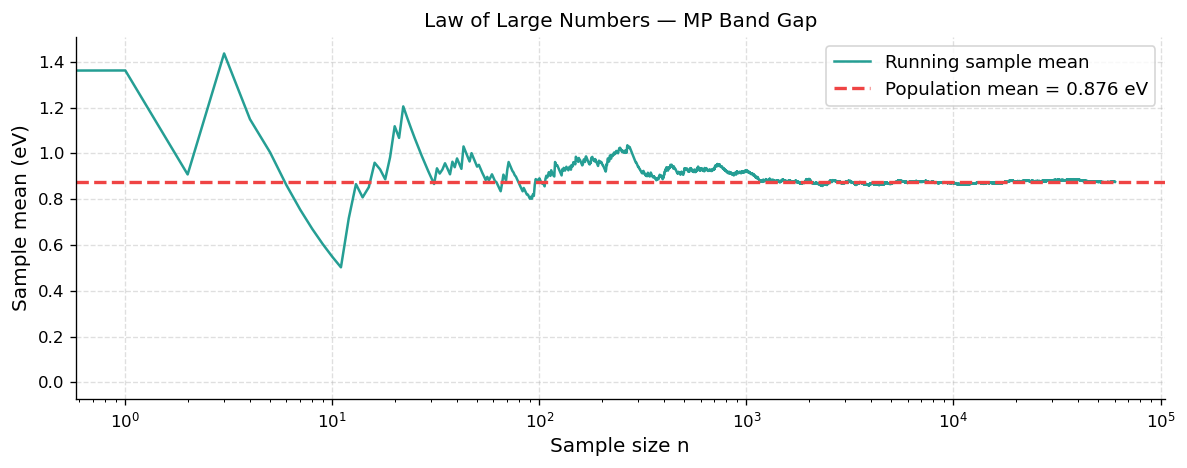

n=    10: sample mean = 0.6028 eV, |error| = 0.2729 eV
n=   100: sample mean = 0.8815 eV, |error| = 0.0057 eV
n=  1000: sample mean = 0.9211 eV, |error| = 0.0453 eV
n= 10000: sample mean = 0.8716 eV, |error| = 0.0042 eV


In [33]:
# Cell C2 — Law of Large Numbers demonstration
# LECTURE DEMO

# Running sample mean as n increases
np.random.seed(0)
bg_shuffled = df['band_gap'].dropna().values.copy()
np.random.shuffle(bg_shuffled)

true_mean = bg_shuffled.mean()
running_mean = np.cumsum(bg_shuffled) / np.arange(1, len(bg_shuffled)+1)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(running_mean, color='#0D9488', lw=1.5, alpha=0.9, label='Running sample mean')
ax.axhline(true_mean, color='#EF4444', ls='--', lw=2, label=f'Population mean = {true_mean:.3f} eV')
ax.set_xlabel('Sample size n', fontsize=12)
ax.set_ylabel('Sample mean (eV)', fontsize=12)
ax.set_title('Law of Large Numbers — MP Band Gap', fontsize=12)
ax.set_xscale('log')
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('C2_LLN.png', dpi=150)
plt.show()

# Quantify convergence
for n in [10, 100, 1000, 10000]:
    error = abs(running_mean[n-1] - true_mean)
    print(f"n={n:6d}: sample mean = {running_mean[n-1]:.4f} eV, |error| = {error:.4f} eV")

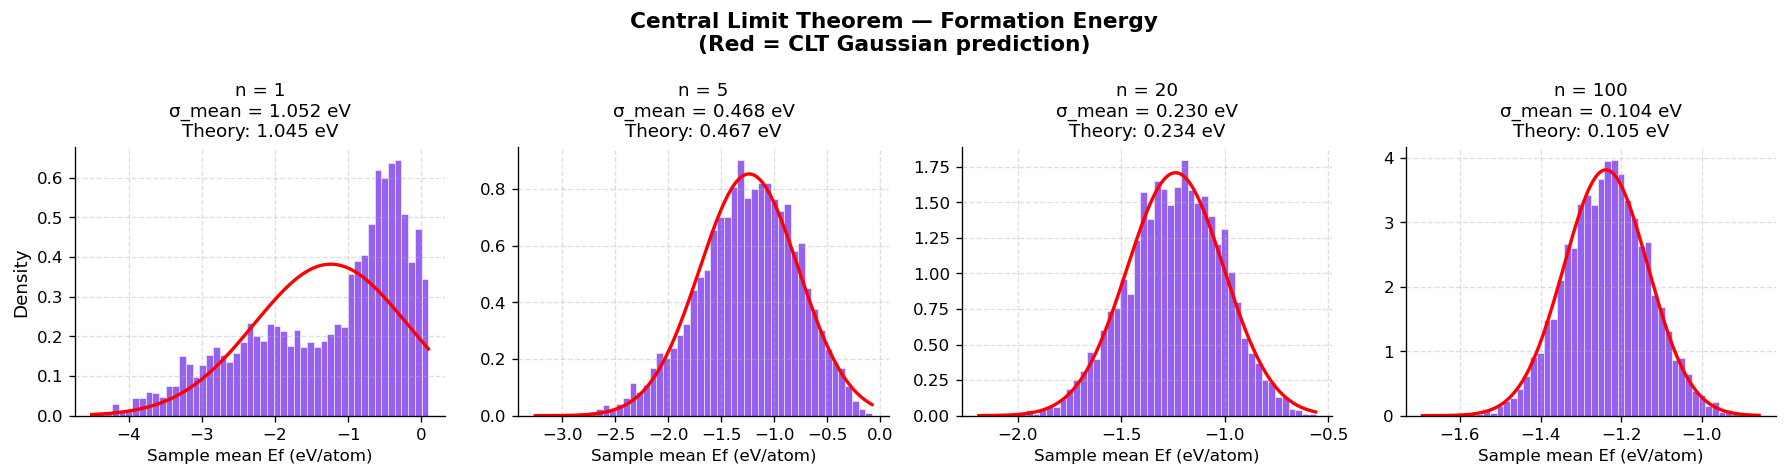

In [34]:
# Cell C3 — Central Limit Theorem demonstration
# LECTURE DEMO

ef_data = df['Ef_eV_atom'].dropna().values
n_sizes = [1, 5, 20, 100]
n_simulations = 5000

fig, axes = plt.subplots(1, 4, figsize=(15, 4))

for ax, n in zip(axes, n_sizes):
    sample_means = [np.mean(np.random.choice(ef_data, n)) for _ in range(n_simulations)]
    ax.hist(sample_means, bins=50, color='#7C3AED', alpha=0.8,
            density=True, edgecolor='white', linewidth=0.4)

    # Overlay theoretical Gaussian (CLT prediction)
    mu_clt = np.mean(ef_data)
    sig_clt = np.std(ef_data, ddof=1) / np.sqrt(n)
    x_range = np.linspace(min(sample_means), max(sample_means), 200)
    ax.plot(x_range, norm.pdf(x_range, mu_clt, sig_clt), 'r-', lw=2)

    ax.set_title(f'n = {n}\nσ_mean = {np.std(sample_means):.3f} eV\nTheory: {sig_clt:.3f} eV', fontsize=11)
    ax.set_xlabel('Sample mean Ef (eV/atom)', fontsize=10)

axes[0].set_ylabel('Density', fontsize=11)
fig.suptitle('Central Limit Theorem — Formation Energy\n(Red = CLT Gaussian prediction)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('C3_CLT.png', dpi=150)
plt.show()

In [35]:
# Cell C4 — Task: 95% confidence interval for mean Ef using CLT
# YOUR CODE HERE

# 1. Compute the 95% confidence interval for the mean formation energy
#    Using the CLT formula: CI = x̄ ± z_{0.025} · σ/√n
#    z_{0.025} = 1.96 (from the standard normal table)
#    Use the full dataset (n = total number of non-null Ef values)


# 2. Now compute a t-interval (using the t-distribution instead of z)
#    Because we're estimating σ from data, the t-distribution is more correct:
#    CI = x̄ ± t_{0.025, df=n-1} · s/√n
#    Use: scipy.stats.t.ppf(0.975, df=n-1)


# 3. Print both CI bounds and the interval width for both approaches
#    Comment: why are they virtually identical for this n?


# 4. How large would n need to be so that the 95% CI width is ≤ 0.01 eV/atom?
#    Show the calculation.

ef = df['Ef_eV_atom'].dropna().values
n       = len(ef)
mean_ef = np.mean(ef)
std_ef  = np.std(ef, ddof=1)
se      = std_ef / np.sqrt(n)

# 1. Z-interval (CLT, z = 1.96)
z       = 1.96
ci_z_low  = mean_ef - z * se
ci_z_high = mean_ef + z * se
width_z   = ci_z_high - ci_z_low

# 2. T-interval (t-distribution, df=n-1)
t_crit    = scipy.stats.t.ppf(0.975, df=n-1)
ci_t_low  = mean_ef - t_crit * se
ci_t_high = mean_ef + t_crit * se
width_t   = ci_t_high - ci_t_low

# 3. Print both CI bounds and widths
print(f"n = {n},  mean Ef = {mean_ef:.4f} eV/atom,  std = {std_ef:.4f} eV/atom")
print(f"\n{'Method':<12} {'Lower':>10} {'Upper':>10} {'Width':>10} {'Critical value':>16}")
print("-" * 62)
print(f"{'Z (1.96)':<12} {ci_z_low:>10.4f} {ci_z_high:>10.4f} {width_z:>10.4f} {z:>16.4f}")
print(f"{'t (df=n-1)':<12} {ci_t_low:>10.4f} {ci_t_high:>10.4f} {width_t:>10.4f} {t_crit:>16.4f}")

print(f"\nThey are virtually identical because n is large, so t → z by CLT.")

# 4. How large does n need to be for CI width ≤ 0.01 eV/atom?
# Width = 2 * 1.96 * std / sqrt(n) ≤ 0.01
# sqrt(n) ≥ 2 * 1.96 * std / 0.01
# n ≥ (2 * 1.96 * std / 0.01)²
target_width = 0.01
n_required   = (2 * 1.96 * std_ef / target_width) ** 2

print(f"\n--- Question 4 ---")
print(f"Target CI width:  ≤ {target_width} eV/atom")
print(f"Formula:          n ≥ (2 × 1.96 × σ / width)²")
print(f"                  n ≥ (2 × 1.96 × {std_ef:.4f} / {target_width})²")
print(f"Required n:       {n_required:.1f}  →  at least {int(np.ceil(n_required))} samples")


n = 60323,  mean Ef = -1.2379 eV/atom,  std = 1.0451 eV/atom

Method            Lower      Upper      Width   Critical value
--------------------------------------------------------------
Z (1.96)        -1.2462    -1.2295     0.0167           1.9600
t (df=n-1)      -1.2462    -1.2295     0.0167           1.9600

They are virtually identical because n is large, so t → z by CLT.

--- Question 4 ---
Target CI width:  ≤ 0.01 eV/atom
Formula:          n ≥ (2 × 1.96 × σ / width)²
                  n ≥ (2 × 1.96 × 1.0451 / 0.01)²
Required n:       167835.8  →  at least 167836 samples


---
## Part D — Correlation Matrix
**Connects to: Lecture 2, Sandfeld Ch. 7**

The correlation matrix is one of the first things you compute for any new dataset. It reveals redundant features and hidden structure-property relationships.

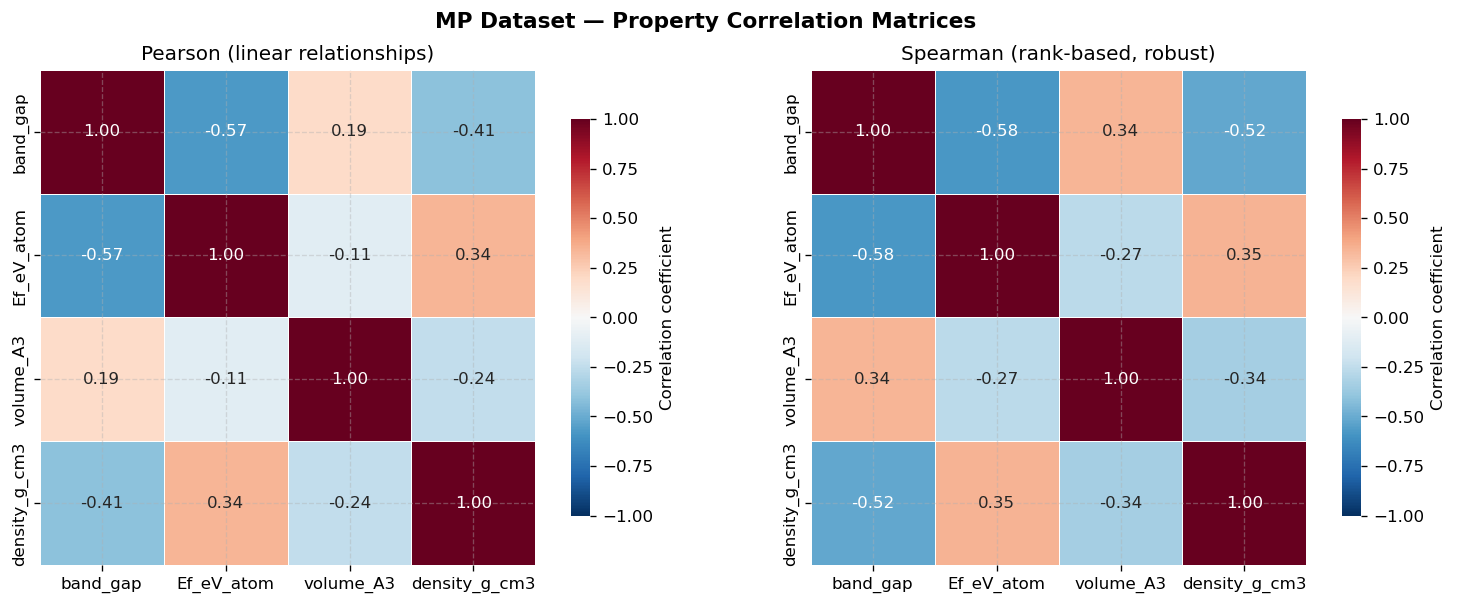

Pearson correlation matrix:
               band_gap  Ef_eV_atom  volume_A3  density_g_cm3
band_gap          1.000      -0.574      0.188         -0.414
Ef_eV_atom       -0.574       1.000     -0.110          0.340
volume_A3         0.188      -0.110      1.000         -0.244
density_g_cm3    -0.414       0.340     -0.244          1.000


In [36]:
# Cell D1 — Pearson and Spearman correlation matrices
# LECTURE DEMO

cols = ['band_gap', 'Ef_eV_atom', 'volume_A3', 'density_g_cm3']
df_num = df[cols].dropna()

corr_p = df_num.corr(method='pearson')
corr_s = df_num.corr(method='spearman')

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 5))

for ax, corr, title in [
    (ax1, corr_p, 'Pearson (linear relationships)'),
    (ax2, corr_s, 'Spearman (rank-based, robust)'),
]:
    sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r',
                center=0, vmin=-1, vmax=1, square=True, ax=ax,
                linewidths=0.5, linecolor='white',
                cbar_kws={'label': 'Correlation coefficient', 'shrink': 0.8})
    ax.set_title(title, fontsize=12)

plt.suptitle('MP Dataset — Property Correlation Matrices', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('D1_correlation_matrices.png', dpi=150)
plt.show()

print("Pearson correlation matrix:")
print(corr_p.round(3))

All correlation pairs (sorted by |ρ|):
  band_gap             vs Ef_eV_atom            ρ = -0.5738
  band_gap             vs density_g_cm3         ρ = -0.4137
  Ef_eV_atom           vs density_g_cm3         ρ = 0.3401
  volume_A3            vs density_g_cm3         ρ = -0.2439
  band_gap             vs volume_A3             ρ = 0.1879
  Ef_eV_atom           vs volume_A3             ρ = -0.1101

Strongest 1: band_gap vs Ef_eV_atom, ρ = -0.5738
Strongest 2: band_gap vs density_g_cm3, ρ = -0.4137
Weakest 1:   Ef_eV_atom vs volume_A3, ρ = -0.1101
Weakest 2:   band_gap vs volume_A3, ρ = 0.1879


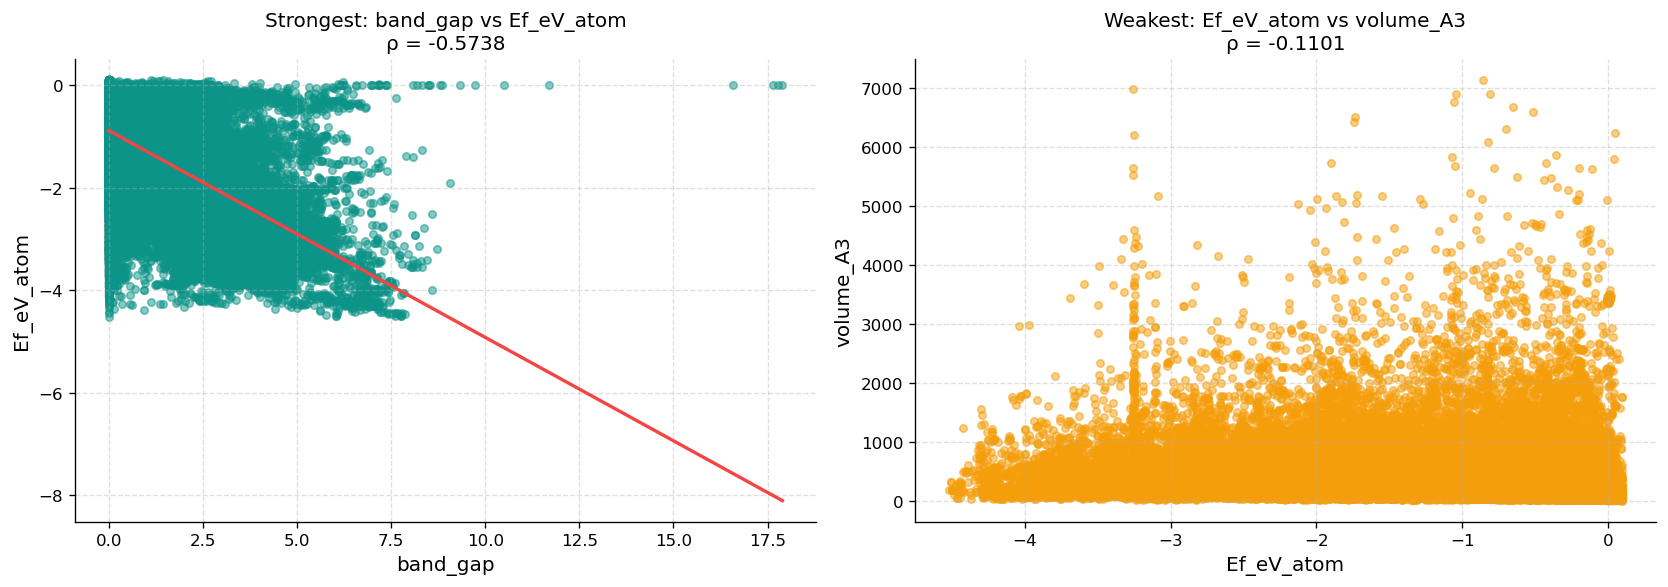

In [37]:
# Cell D2 — Task: identify and physically interpret key correlations
# YOUR CODE HERE

# 1. From the Pearson matrix, extract:
#    - The two most strongly correlated property pairs - positive and negative (highest ρ, excluding diagonal)
#    - The two most weakly correlated property pairs - positive and negative (lowest ρ)
#    Print them with their ρ values


# 2. For the strongest correlation:
#    Make a scatter plot of the two properties
#    Add a best-fit line (use np.polyfit(x, y, 1) or scipy.stats.linregress)
#    Label axes with units, add ρ value to the title


# 3. For the weakest correlation:
#    Make a scatter plot and verify visually that there is no clear trend

import itertools

properties = ['band_gap', 'Ef_eV_atom', 'volume_A3', 'density_g_cm3']
corr_df = df[properties].dropna()

# Pearson correlation matrix
pearson_corr = corr_df.corr(method='pearson')

# Extract upper triangle (exclude diagonal)
pairs = []
for p1, p2 in itertools.combinations(properties, 2):
    r = pearson_corr.loc[p1, p2]
    pairs.append((p1, p2, r))

pairs_sorted = sorted(pairs, key=lambda x: abs(x[2]), reverse=True)

# Two most strongly correlated (highest |ρ|)
strongest1 = pairs_sorted[0]
strongest2 = pairs_sorted[1]

# Two most weakly correlated (lowest |ρ|)
weakest1 = pairs_sorted[-1]
weakest2 = pairs_sorted[-2]

print("All correlation pairs (sorted by |ρ|):")
for p1, p2, r in pairs_sorted:
    print(f"  {p1:20} vs {p2:20}  ρ = {r:.4f}")

print(f"\nStrongest 1: {strongest1[0]} vs {strongest1[1]}, ρ = {strongest1[2]:.4f}")
print(f"Strongest 2: {strongest2[0]} vs {strongest2[1]}, ρ = {strongest2[2]:.4f}")
print(f"Weakest 1:   {weakest1[0]} vs {weakest1[1]}, ρ = {weakest1[2]:.4f}")
print(f"Weakest 2:   {weakest2[0]} vs {weakest2[1]}, ρ = {weakest2[2]:.4f}")

# 2. Scatter plot for strongest correlation
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

x1 = corr_df[strongest1[0]]
y1 = corr_df[strongest1[1]]
m, b = np.polyfit(x1, y1, 1)
ax1.scatter(x1, y1, color='#0D9488', alpha=0.5, s=20)
ax1.plot(np.sort(x1), m * np.sort(x1) + b, color='#F44444', lw=2)
ax1.set_xlabel(strongest1[0], fontsize=12)
ax1.set_ylabel(strongest1[1], fontsize=12)
ax1.set_title(f'Strongest: {strongest1[0]} vs {strongest1[1]}\nρ = {strongest1[2]:.4f}', fontsize=12)
ax1.grid(True, linestyle='--', alpha=0.4)

# 3. Scatter plot for weakest correlation
x2 = corr_df[weakest1[0]]
y2 = corr_df[weakest1[1]]
ax2.scatter(x2, y2, color='#F59E0B', alpha=0.5, s=20)
ax2.set_xlabel(weakest1[0], fontsize=12)
ax2.set_ylabel(weakest1[1], fontsize=12)
ax2.set_title(f'Weakest: {weakest1[0]} vs {weakest1[1]}\nρ = {weakest1[2]:.4f}', fontsize=12)
ax2.grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.savefig('D2_correlations.png', dpi=150)
plt.show()

**D2 Reflection** *(answer in this cell)*

For each of your four identified property pairs, provide a physical explanation:

1. **Strongest positive correlation (ρ > 0):** What physical principle connects these two properties?
2. **Strongest negative correlation (ρ < 0):** Why do these properties move in opposite directions?
3. **Weakest correlation 1:** Why are these two properties essentially independent?
4. **Weakest correlation 2:** Same — what makes them independent?
5. Where do Pearson and Spearman disagree most? What does this tell you about the relationship between those properties?

*Your answer here:*

1. Strongest positive correlation (ρ > 0):
The strongest positive correlation is between band_gap and density_g_cm3 with ρ = 0.4137.
This suggests that materials with higher density tend to have larger band gaps. Physically, denser materials often have atoms packed more closely, which can strengthen bonding interactions and alter the electronic band structure, increasing the energy separation between the valence and conduction bands.

2. Strongest negative correlation (ρ < 0):
The strongest negative correlation is between band_gap and Ef_eV_atom with ρ = -0.5738.
This means that as the formation energy per atom becomes more negative (more thermodynamically stable), the band gap generally increases. A likely explanation is that strongly bonded and chemically stable materials often have more localized electrons and reduced free-electron behavior, which favors insulating or semiconducting characteristics with larger band gaps.

3. Weakest correlation:
The weakest correlation is between Ef_eV_atom and volume_A3 with ρ = -0.1101.
These properties are nearly independent because atomic volume alone does not directly determine thermodynamic stability. Formation energy depends more on chemical bonding, electronic structure, and composition than on the total crystal volume. Therefore, materials with similar volumes can still have very different formation energies.


4. Weakest correlation 2:
The second weakest correlation is between band_gap and volume_A3 with ρ = 0.1879.
This weak relationship indicates that unit-cell volume has only a minor influence on electronic band gap. While crystal structure can affect orbital overlap and electronic behavior, band gap is much more strongly controlled by bonding type, electron configuration, and chemistry than by size alone.

5. Where Pearson and Spearman may disagree most:
Pearson and Spearman correlations would likely disagree most for relationships involving volume_A3, especially Ef_eV_atom vs volume_A3. The scatter plot shows a broad spread with many outliers and no strong linear trend. Pearson measures linear relationships and is sensitive to outliers, while Spearman measures monotonic rank relationships and is less affected by extreme values. A disagreement between them would suggest that the relationship is non-linear, weak, or dominated by clustered distributions rather than a simple straight-line trend.

---
## Part E — Statistical Tests
**Connects to: Lecture 2, Sandfeld Ch. 8**

Metals:     n=35,559, mean=-0.763 eV/atom, std=0.767
Insulators: n=17,464, mean=-2.104 eV/atom, std=1.002

Welch's t-test: t = 155.856, p = 0.00e+00
Significant at α=0.05: True
Cohen's d = 1.503 (|d|>0.8: large effect)


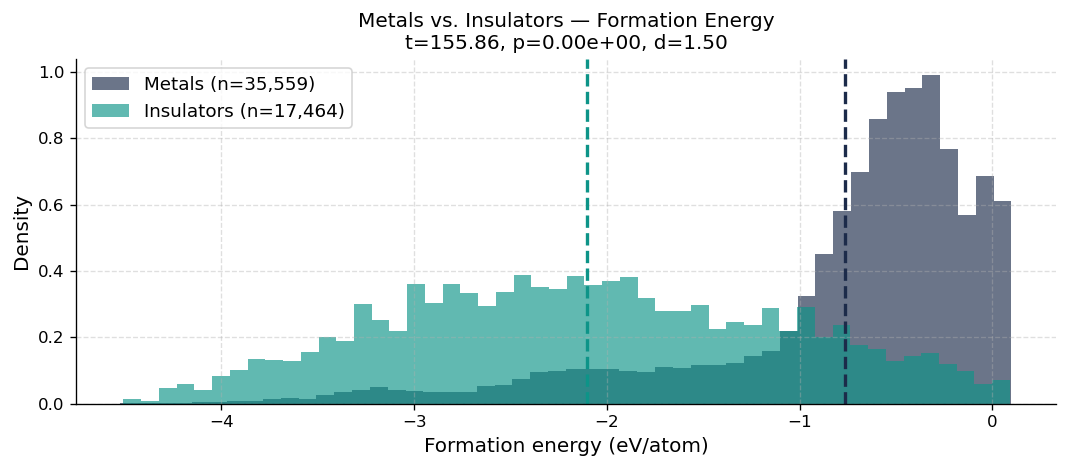

In [38]:
# Cell E1 — Two-sample t-test: metals vs. insulators
# LECTURE DEMO

metals     = df[df['band_gap'] == 0.0]['Ef_eV_atom'].dropna()
insulators = df[df['band_gap'] > 1.0]['Ef_eV_atom'].dropna()

print(f"Metals:     n={len(metals):,}, mean={metals.mean():.3f} eV/atom, std={metals.std():.3f}")
print(f"Insulators: n={len(insulators):,}, mean={insulators.mean():.3f} eV/atom, std={insulators.std():.3f}")

t_stat, p_val = ttest_ind(metals, insulators, equal_var=False)  # Welch's t-test
print(f"\nWelch's t-test: t = {t_stat:.3f}, p = {p_val:.2e}")
print(f"Significant at α=0.05: {p_val < 0.05}")

# Effect size: Cohen's d
pooled_std = np.sqrt((metals.std()**2 + insulators.std()**2) / 2)
cohens_d = (metals.mean() - insulators.mean()) / pooled_std
print(f"Cohen's d = {cohens_d:.3f} (|d|>0.8: large effect)")

# Visualise
fig, ax = plt.subplots(figsize=(9, 4))
ax.hist(metals, bins=50, alpha=0.65, density=True, color='#1C2B4A',
        label=f'Metals (n={len(metals):,})')
ax.hist(insulators, bins=50, alpha=0.65, density=True, color='#0D9488',
        label=f'Insulators (n={len(insulators):,})')
ax.axvline(metals.mean(), color='#1C2B4A', ls='--', lw=2)
ax.axvline(insulators.mean(), color='#0D9488', ls='--', lw=2)
ax.set_xlabel('Formation energy (eV/atom)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title(f'Metals vs. Insulators — Formation Energy\nt={t_stat:.2f}, p={p_val:.2e}, d={cohens_d:.2f}', fontsize=12)
ax.legend(fontsize=11)
plt.tight_layout()
plt.savefig('E1_ttest.png', dpi=150)
plt.show()

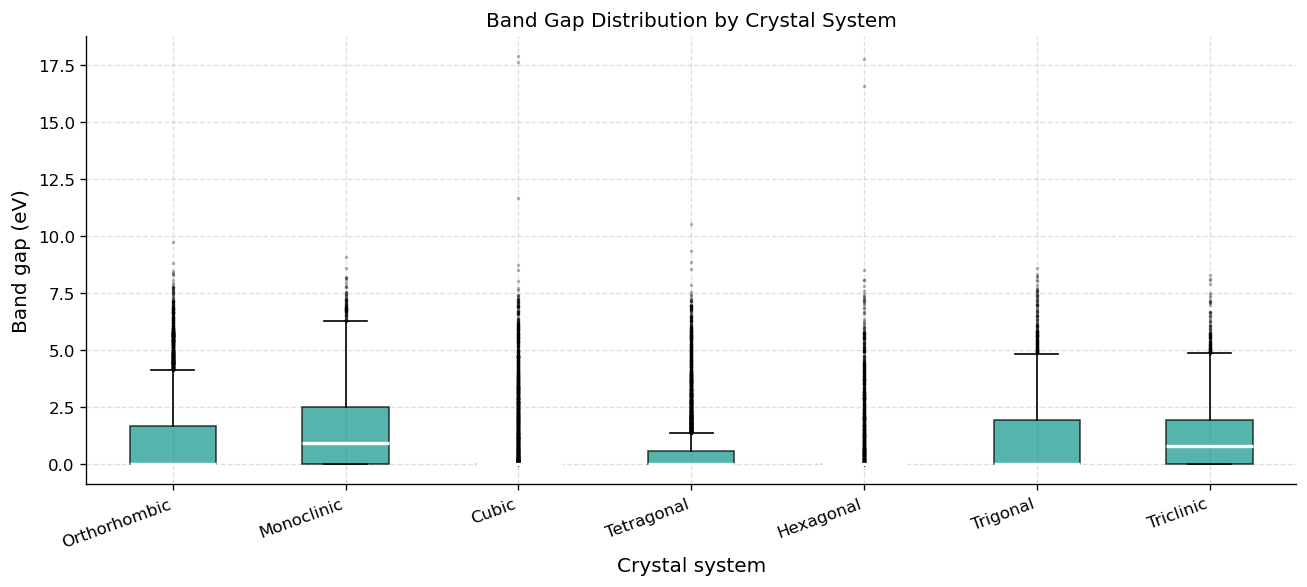

One-way ANOVA: F = 773.55, p = 0.00e+00
Kruskal-Wallis: H = 8301.63, p = 0.00e+00

Median bandgap by crystal system:
  Monoclinic     : median = 0.908 eV, n = 10,944
  Triclinic      : median = 0.782 eV, n = 3,991
  Orthorhombic   : median = 0.000 eV, n = 14,263
  Cubic          : median = 0.000 eV, n = 10,602
  Tetragonal     : median = 0.000 eV, n = 8,262
  Hexagonal      : median = 0.000 eV, n = 6,589
  Trigonal       : median = 0.000 eV, n = 5,672


In [39]:
# Cell E2 — One-way ANOVA: bandgap across crystal systems
# LECTURE DEMO

systems = df['crystal_system'].value_counts()
systems = systems[systems >= 50].index.tolist()

groups = [(cs, df[df['crystal_system'] == cs]['band_gap'].dropna())
          for cs in systems]

labels = [cs for cs, _ in groups]
data   = [g.values for _, g in groups]

# Box plot first — always visualise before testing
fig, ax = plt.subplots(figsize=(11, 5))
bp = ax.boxplot(data,
                tick_labels=labels,
                patch_artist=True, notch=False,
                boxprops=dict(facecolor='#0D9488', alpha=0.7),
                medianprops=dict(color='white', lw=2),
                flierprops=dict(marker='.', markersize=2, alpha=0.3))
ax.set_xlabel('Crystal system', fontsize=12)
ax.set_ylabel('Band gap (eV)', fontsize=12)
ax.set_title('Band Gap Distribution by Crystal System', fontsize=12)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig('E2_boxplot_crystal.png', dpi=150)
plt.show()

# ANOVA
f_stat, p_anova = f_oneway(*[g for _, g in groups])
print(f"One-way ANOVA: F = {f_stat:.2f}, p = {p_anova:.2e}")

# Kruskal-Wallis (non-parametric alternative)
h_stat, p_kw = kruskal(*[g for _, g in groups])
print(f"Kruskal-Wallis: H = {h_stat:.2f}, p = {p_kw:.2e}")

print(f"\nMedian bandgap by crystal system:")
for cs, g in sorted(groups, key=lambda x: x[1].median(), reverse=True):
    print(f"  {cs:15s}: median = {g.median():.3f} eV, n = {len(g):,}")

In [40]:
# Cell E3 — Task: pairwise t-test with effect size
# YOUR CODE HERE

# Choose any two crystal systems from the list above
CS1 = 'Cubic'
CS2 = 'Hexagonal'

group1 = df[df['crystal_system'] == CS1]['band_gap'].dropna()
group2 = df[df['crystal_system'] == CS2]['band_gap'].dropna()

# 1. Print descriptive statistics for each group (n, mean, median, std)


# 2. Run Welch's two-sample t-test (equal_var=False)


# 3. Compute Cohen's d (effect size)
#    Cohen's d = |mean1 - mean2| / pooled_std
#    Convention: d < 0.2 small, 0.2–0.8 medium, > 0.8 large


# 4. Print: t-statistic, p-value, Cohen's d, and your interpretation

# Cell E3 — Task: pairwise t-test with effect size

CS1 = 'Cubic'
CS2 = 'Hexagonal'

group1 = df[df['crystal_system'] == CS1]['band_gap'].dropna()
group2 = df[df['crystal_system'] == CS2]['band_gap'].dropna()

# 1. Descriptive statistics
for name, g in [(CS1, group1), (CS2, group2)]:
    print(f"{name}: n={len(g)}, mean={g.mean():.4f}, "
          f"median={g.median():.4f}, std={g.std():.4f} eV")

# 2. Welch's two-sample t-test
t_stat, p_val = scipy.stats.ttest_ind(group1, group2, equal_var=False)

# 3. Cohen's d
pooled_std = np.sqrt((group1.std()**2 + group2.std()**2) / 2)
cohens_d   = abs(group1.mean() - group2.mean()) / pooled_std

if cohens_d < 0.2:
    effect = "small"
elif cohens_d < 0.8:
    effect = "medium"
else:
    effect = "large"

# 4. Print results
print(f"\nt-statistic:  {t_stat:.4f}")
print(f"p-value:      {p_val:.4e}")
print(f"Cohen's d:    {cohens_d:.4f} ({effect} effect)")
print(f"\nStatistically significant (α=0.05): {p_val < 0.05}")
print(f"Interpretation: The mean band gap of {CS1} ({group1.mean():.4f} eV) "
      f"and {CS2} ({group2.mean():.4f} eV) compounds "
      f"{'differ significantly' if p_val < 0.05 else 'do not differ significantly'}.")

Cubic: n=10602, mean=0.4007, median=0.0000, std=1.1732 eV
Hexagonal: n=6589, mean=0.3164, median=0.0000, std=1.0442 eV

t-statistic:  4.9022
p-value:      9.5767e-07
Cohen's d:    0.0759 (small effect)

Statistically significant (α=0.05): True
Interpretation: The mean band gap of Cubic (0.4007 eV) and Hexagonal (0.3164 eV) compounds differ significantly.


**E3 Reflection** *(answer in this cell)*

1. Is the difference between your two crystal systems statistically significant? (Report t, p, and α)
2. What is the effect size (Cohen's d), and how do you interpret it?
3. In one sentence: what is the physical reason that cubic and hexagonal compounds might have different average bandgaps?
4. **Critical thinking:** if p < 0.05 but Cohen's d = 0.05 (small effect), should you include crystal system as a feature in an ML model? Why or why not?

*Your answer here:*

1. 1. Statistical Significance Yes, the difference is statistically significant. My t = 4.9022 and p = 9.58e-07, well below α = 0.05, so I reject the null hypothesis that cubic and hexagonal compounds have the same mean bandgap.
2. Cohen's d My Cohen's d = 0.0759, which is a small effect. Even though the difference is statistically significant, crystal system explains very little of the actual bandgap variance between the two groups.
3. Physical Reason Cubic compounds have higher symmetry which promotes broader more dispersive energy bands and typically smaller bandgaps, while hexagonal compounds have more directional anisotropic bonding that tends to localize electrons and push the gap wider.
4. Critical Thinking No, even though p < 0.05 confirms the difference is real, my Cohen's d of 0.0759 tells me crystal system barely explains any of the bandgap variance in my dataset. Adding it as an ML feature would likely introduce noise rather than improve predictions and could lead to overfitting on a feature that carries almost no physical signal.

---
## Part F — Reflection
**Take-home · Connects all three lectures**

### F1 — Connecting statistics to ML

In 3–4 sentences, explain how at least two statistical concepts from this week underpin ML methods we will use in Weeks 4–8.

Be specific: name the statistical concept, the ML method it connects to, and the mechanism. For example: *"Standardisation (subtracting E[X] and dividing by Var(X)^0.5) is applied before PCA and regularised regression because these methods are sensitive to the scale of features without standardisation, large-magnitude features dominate the model regardless of their information content."*

Choose different concepts from the example above.

*Your answer here (3–4 sentences, ≥ 2 connections):*

The Gaussian distribution and the Central Limit Theorem underpin linear regression and ordinary least squares — when residuals are approximately normal, OLS gives the minimum-variance unbiased estimator, and confidence intervals on model coefficients are valid. The concept of variance and covariance directly connects to Principal Component Analysis, where PCA finds directions of maximum variance in the feature space to reduce dimensionality before feeding data into models like neural networks or Gaussian process regression. Correlation analysis, specifically identifying redundant features with high |ρ|, informs feature selection for regularized models like LASSO, where correlated features cause unstable coefficient estimates and removing one of a correlated pair improves model interpretability without losing predictive power.

# F2 — Your own research/research interests

Think about a property you measure or compute in your own research.

1. **What distribution would you expect it to follow?** Name the distribution (Gaussian, log-normal, Weibull, Poisson, etc.) and give the physical reason for your choice — not just 'it's common'.

2. **How would you test this?** Describe the statistical test you would use (KS test, Shapiro-Wilk, Q-Q plot, etc.) and what sample size you would need.

3. **What would a non-Gaussian distribution imply for your data analysis?** For example: if you use the sample mean to characterise the property, what does the CLT tell you about when that estimate becomes reliable?

*Your answer here (3 parts, research-specific — not generic):*

1. I would expect the compositional modulation wavelength measured by SAXS in Ti-Nb-O alloys to follow a log-normal distribution because wavelength is a strictly positive quantity that results from multiplicative growth processes during spinodal decomposition, which by the multiplicative CLT produces log-normal rather than Gaussian distributions.
2. I would test this using a KS test comparing the data against both Gaussian and log-normal fits, supplemented by a Q-Q plot against log-normal quantiles. I would need at least 50 samples across different annealing conditions to have enough power to distinguish the two distributions reliably.
3. If the wavelength distribution is log-normal rather than Gaussian, using the sample mean directly would overestimate the typical modulation wavelength since the mean of a log-normal is skewed by large outliers — I should instead use the geometric mean or work in log-space, and my ML model should use ln(wavelength) as the target variable so that regression residuals are more symmetric and the CLT applies more reliably to uncertainty estimates on predictions.

---
## Submission Checklist

Before submitting via LMS (due **Sunday 11:59 PM**):

**Part A — Probability & Distributions**
- [ ] A1a: Poisson plot reproduced and annotated
- [ ] A1b: Temperature dependence + Arrhenius plot completed, Ef extracted from slope
- [ ] A1b Reflection: answered
- [ ] A2a: Gaussian PDF/CDF reproduced, P(hardness > 270 HV) computed
- [ ] A2b: Gaussian fit to hardness data, 95% CI computed and plotted
- [ ] A2b Reflection: answered
- [ ] A3: Log-normal and Weibull plots reproduced

**Part B — Distribution Fitting**
- [ ] B1: MP dataset loaded, shape/missing/summary printed
- [ ] B2: Three histograms produced
- [ ] B3: Gaussian fit to non-metal bandgap, KS test run
- [ ] B4: Gaussian fit to Ef, comparison to B3, reflection answered
- [ ] B5: Log-normal fit, BIC comparison, better model identified

**Part C — Expectation, Variance, CLT**
- [ ] C1: Mean and variance computed from first principles, CV reported
- [ ] C2: LLN running mean plot reproduced
- [ ] C3: CLT demonstration with 4 sample sizes reproduced
- [ ] C4: 95% CI computed (z and t methods), n for CI width ≤ 0.01 calculated

**Part D — Correlation Matrix**
- [ ] D1: Pearson and Spearman matrices computed and plotted
- [ ] D2: Strongest/weakest pairs identified, scatter plots made, reflection answered

**Part E — Statistical Tests**
- [ ] E1: t-test metals vs. insulators reproduced, Cohen's d computed
- [ ] E2: ANOVA and Kruskal-Wallis reproduced, box plot produced
- [ ] E3: Pairwise t-test for chosen crystal systems, effect size, reflection answered

**Part F — Reflection**
- [ ] F1: 3–4 sentences connecting Week 3 statistics to ML (specific, not generic)
- [ ] F2: Your research property — distribution, test, implications

**Final steps**
- [ ] **Kernel → Restart & Run All** — all cells execute without errors
- [ ] All plots display inline
- [ ] All reflection cells filled in (no placeholder text remaining)
- [ ] Save notebook before uploading